# Coursework 1

This notebook is intended to be used as a starting point for your experiments. The instructions can be found in the MLP2025_26_CW1_Spec.pdf (see Learn,  Assignment Submission, Coursework 1). The methods provided here are just helper functions. If you want more complex graphs such as side by side comparisons of different experiments you should learn more about matplotlib and implement them. Before each experiment remember to re-initialize neural network weights and reset the data providers so you get a properly initialized experiment. For each experiment try to keep most hyperparameters the same except the one under investigation so you can understand what the effects of each are.

## Training Boilerplate

Use the below code as a boilerplate to start your experiments. You can add more cells or change the code as you see fit.

In [ ]:
from mlp.penalties import L1Penalty, L2Penalty, L1L2MixPenalty

ROOT = "/Users/matthewgiles/PycharmProjects/mlpractical"
FIGURE_PATH = f"{ROOT}/report/figures"

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import logging
import sys
sys.path.append(ROOT)

from mlp.data_providers import MNISTDataProvider, EMNISTDataProvider
from mlp.layers import AffineLayer, SoftmaxLayer, SigmoidLayer, ReluLayer, CustomActivationLayer
from mlp.errors import CrossEntropySoftmaxError
from mlp.models import MultipleLayerModel
from mlp.initialisers import ConstantInit, GlorotUniformInit
from mlp.learning_rules import AdamLearningRule
from mlp.optimisers import Optimiser

In [ ]:
import os

# Set all the env variables
os.environ["MLP_DATA_DIR"] = os.path.join(ROOT, "data")

In [ ]:
%matplotlib inline
plt.style.use('ggplot')

def train_model_and_plot_stats(
        model, error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True):
    
    # As well as monitoring the error over training also monitor classification
    # accuracy i.e. proportion of most-probable predicted classes being equal to targets
    data_monitors={'acc': lambda y, t: (y.argmax(-1) == t.argmax(-1)).mean()}

    # Use the created objects to initialise a new Optimiser instance.
    optimiser = Optimiser(
        model, error, learning_rule, train_data, valid_data, data_monitors, notebook=notebook)

    # Run the optimiser for num_epochs epochs (full passes through the training set)
    # printing statistics every epoch.
    stats, keys, run_time = optimiser.train(num_epochs=num_epochs, stats_interval=stats_interval)

    # Plot the change in the validation and training set error over training.
    fig_1 = plt.figure(figsize=(8, 4))
    ax_1 = fig_1.add_subplot(111)
    for k in ['error(train)', 'error(valid)']:
        ax_1.plot(np.arange(1, stats.shape[0]) * stats_interval, 
                  stats[1:, keys[k]], label=k)
    ax_1.legend(loc=0)
    ax_1.set_xlabel('Epoch number')
    ax_1.set_ylabel('Error')

    # Plot the change in the validation and training set accuracy over training.
    fig_2 = plt.figure(figsize=(8, 4))
    ax_2 = fig_2.add_subplot(111)
    for k in ['acc(train)', 'acc(valid)']:
        ax_2.plot(np.arange(1, stats.shape[0]) * stats_interval, 
                  stats[1:, keys[k]], label=k)
    ax_2.legend(loc=0)
    ax_2.set_xlabel('Epoch number')
    ax_2.set_xlabel('Accuracy')

    grad_plot, grad_ax = optimiser.plot_grad_flow()

    return stats, keys, run_time, fig_1, ax_1, fig_2, ax_2, grad_plot, grad_ax

In [ ]:
# The below code will set up the data providers, random number
# generator and logger objects needed for training runs. As
# loading the data from file take a little while you generally
# will probably not want to reload the data providers on
# every training run. If you wish to reset their state you
# should instead use the .reset() method of the data providers.

# Seed a random number generator
seed = 111020
rng = np.random.RandomState(seed)
batch_size = 100
# Set up a logger object to print info about the training run to stdout
logger = logging.getLogger()
logger.setLevel(logging.INFO)
logger.handlers = [logging.StreamHandler()]

# Create data provider objects for the MNIST data set
train_data = EMNISTDataProvider('train', batch_size=batch_size, rng=rng)
valid_data = EMNISTDataProvider('valid', batch_size=batch_size, rng=rng)

smooth_train_data = EMNISTDataProvider('train', batch_size=batch_size, rng=rng, smooth_labels=True)
smooth_valid_data = EMNISTDataProvider('valid', batch_size=batch_size, rng=rng, smooth_labels=True)

In [ ]:
def build_model(hidden_dim=128):
    
    input_dim, output_dim = 784, 47

    
    weights_init = GlorotUniformInit(rng=rng)
    biases_init = ConstantInit(0.)
    
    # Create model with TWO hidden layers
    return MultipleLayerModel([
        AffineLayer(input_dim, hidden_dim, weights_init, biases_init), # first hidden layer
        ReluLayer(),
        AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init), # second hidden layer
        ReluLayer(),
        AffineLayer(hidden_dim, output_dim, weights_init, biases_init) # output layer
    ])

In [ ]:
import numpy as np
from mlp.layers import DropoutLayer

dropout = DropoutLayer()

dropout.fprop(np.array([[1, 2, 3], [4, 5, 6]]), evaluation=True)

In [ ]:
# The model set up code below is provided as a starting point.
# You will probably want to add further code cells for the
# different experiments you run.
%pip install tqdm

In [ ]:
# # Setup hyperparameters
# learning_rate = 0.001
# num_epochs = 5
# stats_interval = 1
# error = CrossEntropySoftmaxError()
# learning_rule = AdamLearningRule(learning_rate=learning_rate)
# 
# hidden_dims = [128, 64, 32]
# output_stats = []
# 
# for hidden_dim in hidden_dims:
#     print(f"Training model with hidden_dim={hidden_dim}")
#     model = build_model(hidden_dim=hidden_dim)
#     
#     # Remember to use notebook=False when you write a script to be run in a terminal
#     stats, keys, run_time, fig_1, ax_1, fig_2, ax_2, grad_plot, grad_ax = train_model_and_plot_stats(
#         model, error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True)
#     
#     output_stats.append((hidden_dim, stats, keys))
#     

In [ ]:
def print_latex_rows(packed, acc_decimals: int = 3, err_decimals: int = 3, start_with_and: bool = False):
    """
    Prints results in LaTeX table row format:
         32            &    0.845   &  0.421  &   0.512            \\
    Based on the final epoch values from the packed results.
    """
    
    prefix = " & " if start_with_and else ""
    for width, arr, idx in sorted(packed, key=lambda x: x[0]):
        val_acc = arr[-1, idx["acc(valid)"]]
        train_err = arr[-1, idx["error(train)"]]
        val_err = arr[-1, idx["error(valid)"]]
        print(f"{prefix} {width:<12}& {val_acc:>7.{acc_decimals}f}   & {train_err:>6.{err_decimals}f} & {val_err:>7.{err_decimals}f}   \\\\")

In [ ]:
# print_latex_rows(output_stats)

In [ ]:

def plot_width_accuracy_from_pack(records, epoch_start: int=1, save_path=None, show=True, prefix="width"):
    
    if not records:
        raise ValueError("No data provided.")

    # Use same style as your training plots
    plt.style.use("ggplot")

    # Sort for consistency
    records_sorted = sorted(records, key=lambda t: t[0])
    n_epochs = records_sorted[0][1].shape[0]
    epochs = np.arange(epoch_start, epoch_start + n_epochs)

    # --- Accuracy plot ---
    fig_acc = plt.figure(figsize=(8, 4))
    ax_acc = fig_acc.add_subplot(111)
    for w, arr, idx in records_sorted:
        ax_acc.plot(epochs, arr[:, idx["acc(train)"]], "-", label=f"{prefix} {w}(train)")
        ax_acc.plot(epochs, arr[:, idx["acc(valid)"]], "--", label=f"{prefix} {w}(valid)")
    ax_acc.set_xlabel("Epoch number")
    ax_acc.set_ylabel("Accuracy")
    ax_acc.legend(loc="best")
    fig_acc.tight_layout()

    fig_err = plt.figure(figsize=(8, 4))
    ax_err = fig_err.add_subplot(111)
    for w, arr, idx in records_sorted:
        ax_err.plot(epochs, arr[:, idx["error(train)"]], "-", label=f"{prefix} {w}(train)")
        ax_err.plot(epochs, arr[:, idx["error(valid)"]], "--", label=f"{prefix} {w}(valid)")
    ax_err.set_xlabel("Epoch number")
    ax_err.set_ylabel("Error")
    ax_err.legend(loc="best")
    fig_err.tight_layout()

    if save_path:
        fig_acc.savefig(os.path.join(FIGURE_PATH, f"acc_{save_path}.png"), bbox_inches="tight")
        fig_err.savefig(os.path.join(FIGURE_PATH, f"error_{save_path}.png"), bbox_inches="tight")

    if show:
        plt.show()
    else:
        plt.close(fig_acc)
        plt.close(fig_err)


In [ ]:
# # Your data pasted into a variable named `packed`
# plot_width_accuracy_from_pack(output_stats, save_path=f"acc_curve_width.png")

## Problematic Training

The following experiments show a failed training run. Run the code and investigate the reasons.

In [ ]:
def build_depth_model(depth=1):
    input_dim, output_dim, hidden_dim = 784, 47, 128
        
        
    weights_init = GlorotUniformInit(rng=rng)
    biases_init = ConstantInit(0.)

    
    layers = [
        AffineLayer(input_dim, hidden_dim, weights_init, biases_init), 
        ReluLayer(),
    ]
    
    for _ in range(depth):
        layers.append(AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init))
        layers.append(ReluLayer())
    
    # Add the output layer
    layers.append(AffineLayer(hidden_dim, output_dim, weights_init, biases_init))
    
    return MultipleLayerModel(layers)

In [ ]:
# # Setup hyperparameters
# learning_rate = 0.001
# num_epochs = 5
# stats_interval = 1
# 
# 
# error = CrossEntropySoftmaxError()
# # Use a Adam learning rule
# learning_rule = AdamLearningRule(learning_rate=learning_rate)
# 
# depth = [1, 2, 3]
# 
# output_stats_depth = []
# 
# for d in depth:
#     print(f"Training model with depth={d}")
#     model = build_depth_model(depth=d)
#     
#     # Remember to use notebook=False when you write a script to be run in a terminal
#     stats, keys, run_time, fig_1, ax_1, fig_2, ax_2, grad_plot, grad_ax = train_model_and_plot_stats(
#         model, error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True)
# 
#     output_stats_depth.append((d, stats, keys))
#     

In [ ]:
# print_latex_rows(output_stats_depth)

In [ ]:
# plot_width_accuracy_from_pack(output_stats_depth, save_path=f"curve_depth", prefix="depth")

In [ ]:
def build_regularised_model(reg="dropout", coefficient=0.5, coefficient2=0.5):
    
    depth = 3
    input_dim, output_dim, hidden_dim = 784, 47, 128
        
        
    weights_init = GlorotUniformInit(rng=rng)
    biases_init = ConstantInit(0.)
    
    penalty = None
    
    # Ensure reg is lowercase for comparison
    reg = reg.lower()
    
    if reg == "l1":
        penalty = L1Penalty(coefficient=coefficient)
    elif reg == "l2":
        penalty = L2Penalty(coefficient=coefficient)
    elif reg == "l1l2":
        penalty = L1L2MixPenalty(coefficient, coefficient2)
        
    layers = [
        AffineLayer(input_dim, hidden_dim, weights_init, biases_init), 
        ReluLayer(),
    ]
    
    for _ in range(depth):
        print("Adding hidden layer", _)
        layers.append(AffineLayer(
            hidden_dim, hidden_dim, weights_init, biases_init, weights_penalty=penalty, biases_penalty=None,
        ))
        layers.append(ReluLayer())
        
        if reg == "dropout":
            layers.append(DropoutLayer(incl_prob=coefficient))
    
    # Add the output layer
    layers.append(AffineLayer(
        hidden_dim, output_dim, weights_init, biases_init,
        weights_penalty=penalty, biases_penalty=None,
    ))
    
    return MultipleLayerModel(layers)

In [ ]:
import pandas as pd

# Setup hyperparameters
learning_rate = 0.0001
num_epochs = 5
stats_interval = 1

error = CrossEntropySoftmaxError()
learning_rule = AdamLearningRule(learning_rate=learning_rate)

regs = {
    # "baseline": [""],
    # "dropout": [0.6, 0.7, 0.85, 0.97],
    "dropout": [0.35, 0.55, 0.75, 0.95],#, 0.75, 0.85, 0.97],
    # "l1": [1e-13, 1e-11, 1e-9, 1e-7, 1e-5, 1e-3],
    # "l2": [1e-13, 1e-11, 1e-9, 1e-7, 1e-5, 1e-3],
    # "smooth": [""],
}

df = pd.DataFrame(
    columns=[
        "regularisation",
        "parameter",
        "train_acc",
        "train_err",
        "valid_acc",
        "valid_err",
        "gen_gap",
    ]
)

# Single loop: train + record results
for reg, params in regs.items():
    for param in params:
        print(f"Training model with {reg} param={param}")
        model = build_regularised_model(reg=reg, coefficient=param)

        # Select data
        if reg == "smooth":
            t_data, v_data = smooth_train_data, smooth_valid_data
        else:
            t_data, v_data = train_data, valid_data

        # Train
        stats, keys, run_time, fig_1, ax_1, fig_2, ax_2, grad_plot, grad_ax = train_model_and_plot_stats(
            model, error, learning_rule, t_data, v_data, num_epochs, stats_interval, notebook=False
        )
        
        # Extract metrics
        final_train_acc = stats[-1, keys["acc(train)"]]
        final_train_err = stats[-1, keys["error(train)"]]
        final_valid_acc = stats[-1, keys["acc(valid)"]]
        final_valid_err = stats[-1, keys["error(valid)"]]
        final_gen_gap = final_valid_err - final_train_err

        # Append result
        df.loc[len(df)] = [
            reg,
            param,
            final_train_acc,
            final_train_err,
            final_valid_acc,
            final_valid_err,
            final_gen_gap,
        ]

# View all results
print(df)


In [ ]:
def print_latex_rows2(df, acc_decimals: int = 3, err_decimals: int = 3, start_with_and: bool = False):
    """
    Prints results in LaTeX table row format:
         32            &    0.845   &  0.421  &   0.512            \\
    Based on the final epoch values from the packed results.
    """
    
    for row in df.itertuples():
        print(f" & {row.parameter:<12}& {row.valid_acc:>7.{acc_decimals}f}   & {row.train_err:>6.{err_decimals}f} & {row.valid_err:>7.{err_decimals}f}   \\\\")

In [ ]:


# For each regularisation type output the results in LaTeX format
for reg in regs.keys():
    sub_df = df[df["regularisation"] == reg]
    print_latex_rows2(sub_df)


In [ ]:

# --- L1/L2 plot ---
l1l2_df = df[df["regularisation"].isin(["l1", "l2"])]

plt.figure(figsize=(6, 4))
for reg in ["l1", "l2"]:
    sub_df = l1l2_df[l1l2_df["regularisation"] == reg]
    plt.plot(sub_df["parameter"], sub_df["valid_acc"], marker="o", label=f"{reg.upper()} Validation Accuracy")
    plt.plot(sub_df["parameter"], sub_df["gen_gap"], marker="s", label=f"{reg.upper()} Gen Gap")

plt.xscale("log")
plt.xlabel("Weight Penalty (log scale)")
plt.ylabel("Metric Value")
plt.title("Accuracy and Error by Weight Penalty")
plt.legend()
plt.grid(True, which="both")
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH, f"wd_plot.png"), dpi=300)
plt.close()

In [ ]:

l1l2_params = [(1e-11, 1e-11), (1e-9, 1e-9), (1e-9, 1e-11), (1e-11, 1e-9)]

# Generate a pandas dataframe
l1l2df = pd.DataFrame(
    columns=[
        "l1_coeff",
        "l2_coeff",
        "epoch",
        "train_acc",
        "train_err",
        "valid_acc",
        "valid_err",
        "gen_gap",
    ]
)


for (l1_coeff, l2_coeff) in l1l2_params:
    print(f"Training model with L1 coeff={l1_coeff}, L2 coeff={l2_coeff}")
    model = build_regularised_model(reg="l1l2", coefficient=l1_coeff, coefficient2=l2_coeff)

    # Train
    stats, keys, run_time, fig_1, ax_1, fig_2, ax_2, grad_plot, grad_ax = train_model_and_plot_stats(
        model, error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True
    )
    
    # Loop through the stats and add them to the plot
    for epoch in range(num_epochs):

        # Extract metrics
        final_train_acc = stats[epoch, keys["acc(train)"]]
        final_train_err = stats[epoch, keys["error(train)"]]
        final_valid_acc = stats[epoch, keys["acc(valid)"]]
        final_valid_err = stats[epoch, keys["error(valid)"]]
        final_gen_gap = final_valid_err - final_train_err

        # Append result
        df.loc[len(df)] = [
            l1_coeff,
            l2_coeff,
            epoch + 1,
            final_train_acc,
            final_train_err,
            final_valid_acc,
            final_valid_err,
            final_gen_gap,
        ]

In [ ]:
import matplotlib.pyplot as plt

def acc_and_gen_gap_plots_l1_l2(df):
    # Group by l1 and l2 coefficients
    grouped = df.groupby(['l1_coeff', 'l2_coeff'])

    for (l1_coeff, l2_coeff), group in grouped:
        # Sort by epoch for consistent plotting
        group = group.sort_values('epoch')

        fig, axes = plt.subplots(1, 2, figsize=(10, 4))
        fig.suptitle(f"L1={l1_coeff:.0e}, L2={l2_coeff:.0e}")

        # Validation accuracy
        axes[0].plot(group['epoch'], group['valid_acc'], label='Validation Accuracy', color='blue')
        axes[0].plot(group['epoch'], group['train_acc'], label='Training Accuracy', linestyle='--', color='grey')
        axes[0].set_title('Accuracy vs Epoch')
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Accuracy')
        axes[0].legend()
        axes[0].grid(True, linestyle=':')

        # Generalisation gap
        axes[1].plot(group['epoch'], group['gen_gap'], label='Gen Gap', color='red')
        axes[1].set_title('Generalisation Gap vs Epoch')
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Validation Error - Training Error')
        axes[1].grid(True, linestyle=':')
        axes[1].legend()

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        
        # Save the figure
        fig.savefig(os.path.join(FIGURE_PATH, f"l1_{l1_coeff:.0e}_l2_{l2_coeff:.0e}_acc_gen_gap.png"), dpi=300)
        plt.close(fig)
        plt.show()


In [123]:
def print_latex_l1_l2(df):
    #     \# L1 Coefficient & L2 Coefficient & Val. Acc. & Train Error & Val. Error \\
    for (l1_coeff, l2_coeff), group in df.groupby(['l1_coeff', 'l2_coeff']):
        final_row = group.iloc[-1]
        print(f"{l1_coeff:<12.0e}& {l2_coeff:<12.0e}& {final_row.valid_acc:>7.3f}   & {final_row.train_err:>6.3f} & {final_row.valid_err:>7.3f}   \\\\")

In [124]:
print_latex_l1_l2(df)

1e-11       & 1e-11       &   0.747   &  0.828 &   0.845   \\
1e-11       & 1e-09       &   0.744   &  0.847 &   0.866   \\
1e-09       & 1e-11       &   0.750   &  0.823 &   0.836   \\
1e-09       & 1e-09       &   0.751   &  0.794 &   0.818   \\


In [ ]:
acc_and_gen_gap_plots_l1_l2(l1l2df)

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1: 19.1s to complete
    error(train)=3.85e+00, acc(train)=2.12e-02, error(valid)=3.85e+00, acc(valid)=2.15e-02


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 2: 19.0s to complete
    error(train)=3.85e+00, acc(train)=2.17e-02, error(valid)=3.85e+00, acc(valid)=1.96e-02


...

Epoch 3: 16.3s to complete
    error(train)=3.85e+00, acc(train)=2.17e-02, error(valid)=3.85e+00, acc(valid)=2.01e-02


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 4: 19.2s to complete
    error(train)=3.85e+00, acc(train)=2.17e-02, error(valid)=3.85e+00, acc(valid)=1.98e-02


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 5: 21.6s to complete
    error(train)=3.85e+00, acc(train)=2.13e-02, error(valid)=3.85e+00, acc(valid)=2.08e-02


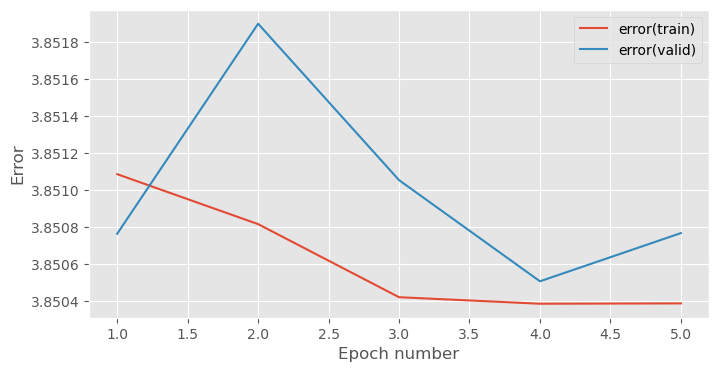

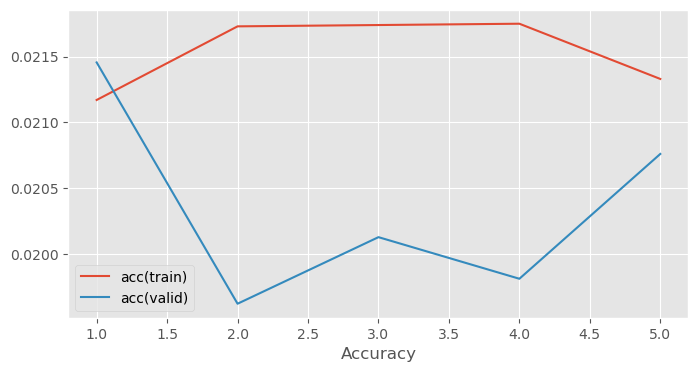

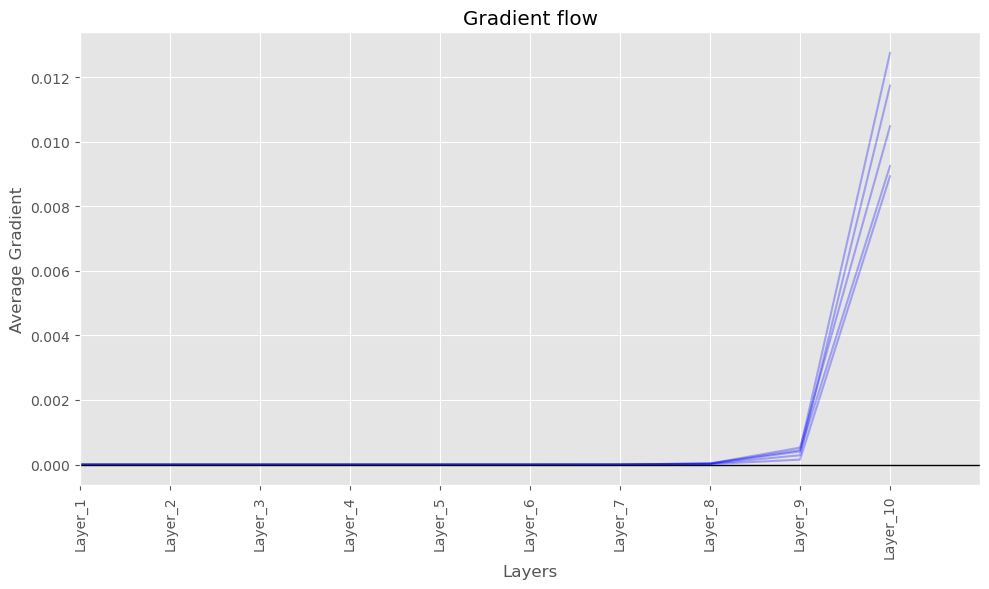

In [116]:
# Setup hyperparameters
learning_rate = 0.001
num_epochs = 5
stats_interval = 1

def custom_activation_model():
    
    input_dim, output_dim, hidden_dim = 784, 47, 128
    weights_init = GlorotUniformInit(rng=rng)
    biases_init = ConstantInit(0.)


    # Create model with four hidden layer
    return MultipleLayerModel([
        AffineLayer(input_dim, hidden_dim, weights_init, biases_init), 
        CustomActivationLayer(), 
        AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init),
        CustomActivationLayer(),
        AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init),
        CustomActivationLayer(),
        AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init),
        CustomActivationLayer(),
        AffineLayer(hidden_dim, output_dim, weights_init, biases_init) # output layer
    ])
    
model = custom_activation_model()

error = CrossEntropySoftmaxError()
# Use a Adam learning rule
learning_rule = AdamLearningRule(learning_rate=learning_rate)

# Remember to use notebook=False when you write a script to be run in a terminal
problematic_stats, keys, run_time, fig_1, ax_1, fig_2, ax_2, grad_plot, grad_ax = train_model_and_plot_stats(
    model, error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True)

In [117]:
problematic_stats = stats

In [120]:
# Save the gradient flow plot
grad_plot.savefig(os.path.join(FIGURE_PATH, f"custom_activation_grad_flow.png"), bbox_inches="tight")


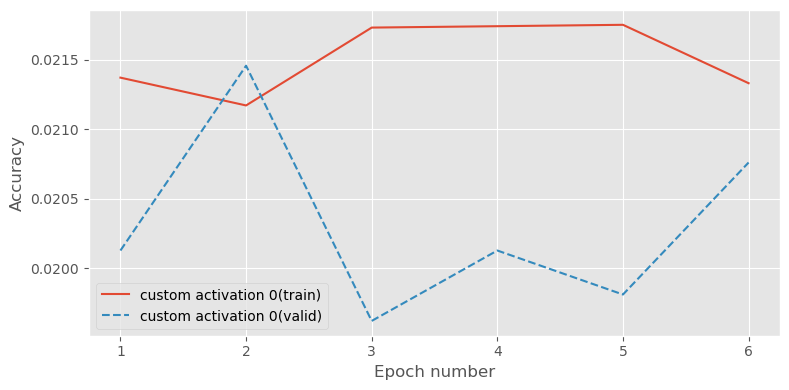

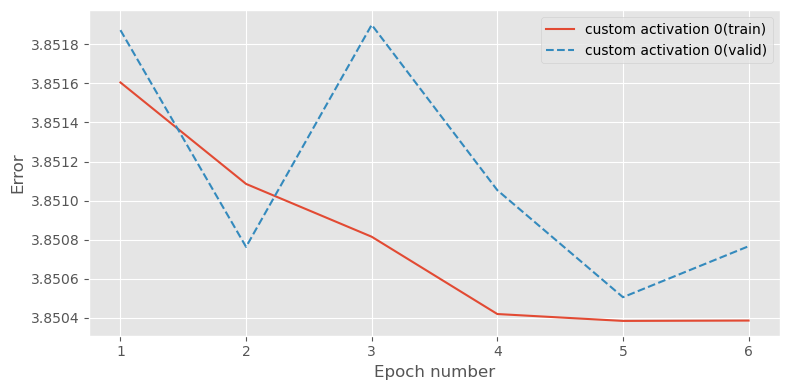

In [119]:
plot_width_accuracy_from_pack([(0, problematic_stats, keys)], save_path="custom_activation_curve", prefix="custom activation")